# CelebA OOD Certification Analysis

1. Classifier performance (base + OOD)
2. OOD certification results loaded
3. **Per-attribute per-σ detail table** (CertAcc, Abstain, SmileAcc, NoSmileAcc, log V_iso, log V_mani)
4. Figures: certified accuracy, smile/no-smile, peak accuracy, certified radius

In [8]:
import sys, os, json
sys.path.insert(0, os.path.abspath('..'))

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches

plt.rcParams.update({
    'font.family':        'serif',
    'font.size':          11,
    'axes.labelsize':     12,
    'axes.titlesize':     13,
    'legend.fontsize':    9,
    'xtick.labelsize':    10,
    'ytick.labelsize':    10,
    'figure.dpi':         120,
    'axes.spines.top':    False,
    'axes.spines.right':  False,
    'axes.grid':          True,
    'grid.alpha':         0.3,
    'grid.linestyle':     '--',
})

C    = {'manifold': '#f5c518', 'isotropic': '#2166ac',
        'smile': '#1b7837',   'no_smile':  '#762a83',
        'overall': '#636363'}
LS   = {'Manifold': '-',  'Isotropic': '--'}
COL  = {'Manifold': C['manifold'], 'Isotropic': C['isotropic']}
MARK = {'Manifold': 'o', 'Isotropic': 's'}

REPO_ROOT   = Path(os.path.abspath('..'))
OUTPUT      = REPO_ROOT / 'output'
MODELS_DIR  = OUTPUT / 'smile_resnet_celeba'
OOD_MODELS  = sorted([p for p in OUTPUT.iterdir()
                       if p.is_dir() and p.name.startswith('smile_resnet_celeba_ood_')])
CERTIFY_DIR = OUTPUT / 'smile_classification' / 'celeba' / 'certify_ood'

SIGMA_VALUES = [0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50,
                0.55, 0.60, 0.65, 0.70, 0.75, 0.80, 0.85, 0.90, 0.95,
                1.00, 1.50, 2.00]

def sigma_tag(v): return f'sigma_{v:.2f}'.replace('.','_')
def load_json(p):
    p = Path(p)
    return json.loads(p.read_text()) if p.exists() else None

print('Base model exists:', MODELS_DIR.exists())
print('OOD models found: ', len(OOD_MODELS))
print('Certify_ood dir:  ', CERTIFY_DIR.exists())

Base model exists: True
OOD models found:  11
Certify_ood dir:   True


## 1. Classifier Performance Table

In [9]:
clf_rows = []

def parse_clf(path, label):
    m = load_json(path)
    if m is None: return None
    total = m.get('test_smile_total', 0) + m.get('test_no_smile_total', 0)
    return {
        'Model':          label,
        'N test':         total,
        'Smile %':        round(100 * m.get('test_smile_total', 0) / total, 1) if total else 0,
        'Test acc':       round(100 * m.get('test_acc',          0), 2),
        'Smile acc':      round(100 * m.get('test_smile_acc',    0), 2),
        'Non-smile acc':  round(100 * m.get('test_no_smile_acc', 0), 2),
        # 'Best val acc':   round(100 * m.get('best_val_acc',      0), 2),
        'OOD exclude':    m.get('ood_exclude_attribute', None),
    }

r = parse_clf(MODELS_DIR / 'metrics.json', 'Base (all data)')
if r: clf_rows.append(r)

for d in OOD_MODELS:
    attr = d.name.replace('smile_resnet_celeba_ood_', '').replace('_',' ').title()
    r = parse_clf(d / 'metrics.json', f'OOD – {attr}')
    if r: clf_rows.append(r)

clf_df = pd.DataFrame(clf_rows)

# OOD classifier reference dict
OOD_CLF_REF = {}
for _, row in clf_df.iterrows():
    excl = row.get('OOD exclude')
    if isinstance(excl, str) and excl:
        OOD_CLF_REF[excl.lower()] = row

# Base reference
base_row        = clf_df[clf_df['OOD exclude'].isna()].iloc[0] if not clf_df.empty else None
BASE_TEST_ACC   = base_row['Test acc']      if base_row is not None else np.nan
BASE_SMILE_ACC  = base_row['Smile acc']     if base_row is not None else np.nan
BASE_NSMILE_ACC = base_row['Non-smile acc'] if base_row is not None else np.nan

print(f'Base classifier (all data) — test: {BASE_TEST_ACC:.1f}%  '
      f'smile: {BASE_SMILE_ACC:.1f}%  no-smile: {BASE_NSMILE_ACC:.1f}%')
print(f'OOD classifiers loaded: {sorted(OOD_CLF_REF.keys())}')
# 'Best val acc'
display(clf_df[['Model','N test','Smile %','Test acc','Smile acc','Non-smile acc']]
        .style
        .format({'N test':'{:,}','Smile %':'{:.1f}%','Test acc':'{:.1f}%',
                 'Smile acc':'{:.1f}%','Non-smile acc':'{:.1f}%','Best val acc':'{:.1f}%'})
        .background_gradient(subset=['Test acc','Smile acc','Non-smile acc'],
                             cmap='Blues', vmin=80, vmax=100)
        .set_caption('Classifier Performance — Base (all data) and OOD (excl. attr=1) Models'))

Base classifier (all data) — test: 92.0%  smile: 93.8%  no-smile: 90.3%
OOD classifiers loaded: ['big_lips', 'eyeglasses', 'high_cheekbones', 'male', 'mouth_slightly_open', 'mustache', 'narrow_eyes', 'no_beard', 'rosy_cheeks', 'wearing_hat', 'wearing_lipstick']


,Model,N test,Smile %,Test acc,Smile acc,Non-smile acc
0,Base (all data),"20,261",48.3%,92.0%,93.8%,90.3%
1,OOD – Big Lips,"4,847",50.0%,92.5%,93.5%,91.4%
2,OOD – Eyeglasses,"1,304",40.0%,89.5%,82.5%,93.9%
3,OOD – High Cheekbones,"9,275",85.8%,91.3%,92.2%,85.5%
4,OOD – Male,"8,452",39.9%,90.2%,84.9%,93.5%
5,OOD – Mouth Slightly Open,"9,783",75.9%,92.6%,92.4%,93.4%
6,OOD – Mustache,834,31.5%,88.0%,94.3%,85.5%
7,OOD – Narrow Eyes,"2,301",58.3%,93.6%,95.2%,91.2%
8,OOD – No Beard,"16,943",50.9%,90.4%,88.2%,92.6%
9,OOD – Rosy Cheeks,"1,314",89.6%,95.2%,96.7%,79.4%


In [6]:
## Dataset split sizes — new OOD no-leakage setup
#
# Split logic (matches celeba_smile.py):
#   train:       attr=0, train partition  → classifier trains on non-OOD only
#   val:         attr=1, val partition    → early stopping on OOD
#   test:        attr=1, test partition   → classifier test_acc (metrics.json)
#   certify_ood: attr=1, TRAIN partition  → certification (truly unseen, not in val/test)

import random as _random
from pathlib import Path as _Path

CELEBA_ROOT = _Path('/BS/databases08/CelebA')
ATTR_FILE   = CELEBA_ROOT / 'Anno' / 'list_attr_celeba.txt'
SPLIT_SEED  = 73
TRAIN_RATIO = 0.8
VAL_RATIO   = 0.1

if not ATTR_FILE.exists():
    print(f'Attribute file not found: {ATTR_FILE}')
else:
    lines      = [l.strip() for l in ATTR_FILE.read_text().splitlines() if l.strip()]
    attr_names = lines[1].split()
    attr_data  = {}
    for line in lines[2:]:
        parts = line.split()
        attr_data[parts[0]] = {attr_names[i]: int(parts[1+i]) for i in range(len(attr_names))}

    all_fnames = list(attr_data.keys())
    rng = _random.Random(SPLIT_SEED)
    shuffled = list(all_fnames); rng.shuffle(shuffled)
    n_train = int(len(shuffled) * TRAIN_RATIO)
    n_val   = int(len(shuffled) * VAL_RATIO)
    train_partition = set(shuffled[:n_train])
    val_partition   = set(shuffled[n_train:n_train+n_val])
    test_partition  = set(shuffled[n_train+n_val:])

    def split_stats(fnames):
        total = len(fnames)
        smile = sum(1 for f in fnames if attr_data[f].get('Smiling', -1) == 1)
        return total, smile, total - smile

    split_rows = []

    def add_row(label, tr, vl, te, certify):
        tr_n, tr_s, tr_ns = split_stats(tr)
        te_n, te_s, te_ns = split_stats(te)
        ce_n = len(certify)
        split_rows.append({
            'Attribute':           label,
            'Train N (attr=0)':    tr_n,
            'Train smile%':        round(100*tr_s/tr_n,  1) if tr_n else 0,
            # 'Val N (attr=1)':      len(vl),
            'Test N (attr=1)':     te_n,
            'Test smile%':         round(100*te_s/te_n,  1) if te_n else 0,
            'Certify N (attr=1)':  ce_n,
            '% train kept':        round(100*tr_n/len(train_partition), 1),
        })

    # Base (no OOD filter)
    add_row('Base (no filter)',
            list(train_partition), list(val_partition),
            list(test_partition),  [])

    # Each OOD attribute
    for attr_key in sorted(OOD_CLF_REF.keys()):
        match = next((a for a in attr_names if a.lower() == attr_key), None)
        if match is None: continue
        is_ood = lambda f, m=match: attr_data[f].get(m, -1) == 1

        train_attr0   = [f for f in train_partition if not is_ood(f)]
        val_attr1     = [f for f in val_partition   if     is_ood(f)]
        test_attr1    = [f for f in test_partition  if     is_ood(f)]
        certify_attr1 = [f for f in train_partition if     is_ood(f)]  # truly unseen

        add_row(match, train_attr0, val_attr1, test_attr1, certify_attr1)

    split_df = pd.DataFrame(split_rows)
    # 'Val N (attr=1)':'{:,}',
    display(split_df.style
            .format({'Train N (attr=0)':'{:,}', 
                     'Test N (attr=1)':'{:,}',  'Certify N (attr=1)':'{:,}',
                     'Train smile%':'{:.1f}%',  'Test smile%':'{:.1f}%',
                     '% train kept':'{:.1f}%'})
            .background_gradient(subset=['% train kept'], cmap='Blues', vmin=0, vmax=100)
            .background_gradient(subset=['Test smile%','Train smile%'], cmap='RdYlGn', vmin=0, vmax=100)
            .set_caption('OOD split sizes — new no-leakage setup (requires retraining to take effect)'))

,Attribute,Train N (attr=0),Train smile%,Test N (attr=1),Test smile%,Certify N (attr=1),% train kept
0,Base (no filter),"162,079",48.2%,"20,261",48.3%,0,100.0%
1,Big_Lips,"123,047",47.9%,"4,847",50.0%,"39,032",75.9%
2,Eyeglasses,"151,520",48.8%,"1,304",40.0%,"10,559",93.5%
3,High_Cheekbones,"88,314",17.0%,"9,275",85.8%,"73,765",54.5%
4,Male,"94,586",54.0%,"8,452",39.9%,"67,493",58.4%
5,Mouth_Slightly_Open,"83,673",22.3%,"9,783",75.9%,"78,406",51.6%
6,Mustache,"155,386",48.9%,834,31.5%,"6,693",95.9%
7,Narrow_Eyes,"143,407",46.8%,"2,301",58.3%,"18,672",88.5%
8,No_Beard,"26,703",35.6%,"16,943",50.9%,"135,376",16.5%
9,Rosy_Cheeks,"151,411",45.3%,"1,314",89.6%,"10,668",93.4%


## 2. Figure — Classifier Accuracy Comparison

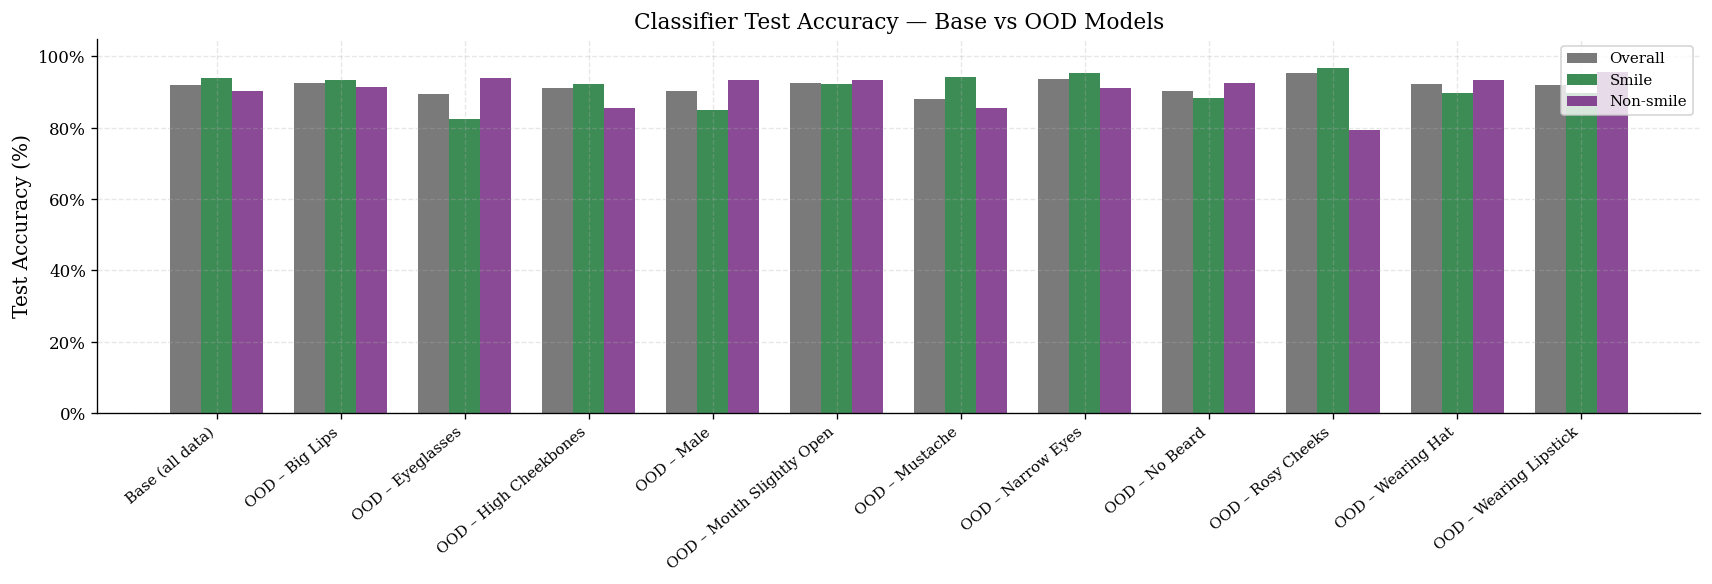

In [4]:
if not clf_df.empty:
    models = clf_df['Model'].tolist()
    x, w   = np.arange(len(models)), 0.25
    fig, ax = plt.subplots(figsize=(max(10, len(models)*1.2), 5))
    ax.bar(x-w, clf_df['Test acc'],      w, label='Overall',   color=C['overall'],  alpha=0.85)
    ax.bar(x,   clf_df['Smile acc'],     w, label='Smile',     color=C['smile'],    alpha=0.85)
    ax.bar(x+w, clf_df['Non-smile acc'], w, label='Non-smile', color=C['no_smile'], alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(models, rotation=40, ha='right', fontsize=9)
    ax.set_ylabel('Test Accuracy (%)')
    ax.set_title('Classifier Test Accuracy — Base vs OOD Models')
    ax.set_ylim(0, 105)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter())
    ax.legend()
    plt.tight_layout()
    plt.savefig('fig_clf_accuracy.pdf', bbox_inches='tight')
    plt.show()

## 3. Load OOD Certification Results

In [ ]:
cert_rows = []

if not CERTIFY_DIR.exists():
    print('certify_ood not found — run OOD certification first')
else:
    for attr_dir in sorted(CERTIFY_DIR.iterdir()):
        if not attr_dir.is_dir(): continue
        attribute = attr_dir.name
        for mode_dir in sorted(attr_dir.iterdir()):
            if not mode_dir.is_dir(): continue
            smoothing = 'Manifold' if 'manifold' in mode_dir.name else 'Isotropic'
            for s in SIGMA_VALUES:
                m = load_json(mode_dir / sigma_tag(s) / 'metrics.json')
                if m is None: continue
                vol  = m.get('volume', {}) or {}
                geo  = vol.get('geometry', {}) or {}   # nested geometry sub-dict (Jonas framework)
                cert_rows.append({
                    'Attribute':   attribute,
                    'Smoothing':   smoothing,
                    'σ':           float(s),
                    'CertAcc':     m.get('certified_accuracy',      np.nan),
                    'Abstain':     m.get('abstain_rate',            np.nan),
                    'SmileAcc':    m.get('class_smile_accuracy',    np.nan),
                    'NoSmileAcc':  m.get('class_no_smile_accuracy', np.nan),
                    'MeanRadius':  m.get('mean_radius',             np.nan),
                    'N test':      m.get('total_test_samples',      np.nan),
                    # Geometry-first volume (Jonas framework) — nested under volume.geometry
                    # log V_iso,geo  = log(C_k · σ^k)              — iso baseline in k-dim space
                    # log V_mani,geo = log(C_k · σ^k · √det(Λ̃))   — manifold volume (normalised evals)
                    # log_geo_ratio  = log V_mani,geo − log V_iso,geo  — pure geometry gain
                    'logV_iso_geo':  geo.get('log_v_iso_geo',        None),
                    'logV_mani_geo': geo.get('mean_log_v_mani_geo',  None),
                    'log_geo_ratio': geo.get('mean_log_geo_ratio',   None),
                })

cert_df = pd.DataFrame(cert_rows) if cert_rows else pd.DataFrame()
if cert_df.empty:
    print('No certification results found.')
else:
    print(f'Rows: {len(cert_df)}')
    print(f'Attributes: {sorted(cert_df.Attribute.unique())}')
    print(f'Smoothing:  {sorted(cert_df.Smoothing.unique())}')
    # Check geometry fields populated for manifold
    mani = cert_df[cert_df['Smoothing']=='Manifold']
    print(f'Manifold rows with logV_mani_geo: {mani["logV_mani_geo"].notna().sum()} / {len(mani)}')

## 4. Per-Attribute Per-σ Detail Table

For each OOD attribute the header shows the **OOD classifier's own test accuracy**
(trained excluding attr=1 images, tested on non-OOD test split).
Certification columns show results on the 100 OOD test images (attr=1).

In [ ]:
if not cert_df.empty:

    def fmt_optional(v, fmt='{:.2f}'):
        return fmt.format(v) if v is not None and not (isinstance(v, float) and np.isnan(v)) else '–'

    for attribute in sorted(cert_df['Attribute'].unique()):
        attr_label = attribute.replace('_', ' ').title()

        ref = OOD_CLF_REF.get(attribute.lower(), None)
        if ref is not None:
            ref_smile  = ref['Smile acc']
            ref_nsmile = ref['Non-smile acc']
            ref_test   = ref['Test acc']
            ref_ntrain = int(ref.get('N test', 0))
            ref_str    = (f"OOD classifier test acc: {ref_test:.1f}%  "
                          f"smile: {ref_smile:.1f}%  no-smile: {ref_nsmile:.1f}%  "
                          f"(N={ref_ntrain:,}, trained excl. {attr_label}=1)")
        else:
            ref_smile = ref_nsmile = ref_test = np.nan
            ref_str = "OOD classifier not found"

        print(f'\n{"═"*100}')
        print(f'  {attr_label}   |   100 OOD test samples (attr=1)   |   100 MC samples')
        print(f'  {ref_str}')
        print(f'{"═"*100}')

        sub = cert_df[cert_df['Attribute'] == attribute].copy()
        table_rows = []
        for smoothing in ['Isotropic', 'Manifold']:
            grp = sub[sub['Smoothing'] == smoothing].sort_values('σ')
            if grp.empty: continue
            for _, r in grp.iterrows():
                table_rows.append({
                    'Smoothing':       smoothing,
                    'σ':               f"{r['σ']:.2f}",
                    'CertAcc':         f"{r['CertAcc']*100:.1f}%",
                    'Abstain':         f"{r['Abstain']*100:.1f}%",
                    'SmileAcc':        f"{r['SmileAcc']*100:.1f}%",
                    'NoSmileAcc':      f"{r['NoSmileAcc']*100:.1f}%",
                    # Geometry-first (Jonas): log V_iso,geo available for both modes;
                    # log V_mani,geo and log_geo_ratio only for manifold
                    'log V_iso,geo':   fmt_optional(r['logV_iso_geo'],  '{:.2f}'),
                    'log V_mani,geo':  fmt_optional(r['logV_mani_geo'], '{:.2f}'),
                    'Δ log V (gain)':  fmt_optional(r['log_geo_ratio'], '{:.3f}'),
                })

        tbl_df = pd.DataFrame(table_rows)

        def highlight_smoothing(row):
            return ['background-color: #fff8e1']*len(row) if row['Smoothing']=='Manifold' else ['']*len(row)

        display(tbl_df.style
                .apply(highlight_smoothing, axis=1)
                .set_caption(
                    f'{attr_label} — OOD clf: smile={ref_smile:.1f}%  '
                    f'no-smile={ref_nsmile:.1f}%  overall={ref_test:.1f}%  '
                    f'| log V_mani,geo > log V_iso,geo → manifold gains volume → more certifiable'))

## 5. Figure — Certified Accuracy vs σ per Attribute (ISO vs Manifold)

In [ ]:
if not cert_df.empty:
    attributes = sorted(cert_df['Attribute'].unique())
    ncols = min(3, len(attributes))
    nrows = int(np.ceil(len(attributes) / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(6*ncols, 4.5*nrows),
                             sharey=True, squeeze=False)

    for i, attr in enumerate(attributes):
        ax  = axes[i // ncols][i % ncols]
        sub = cert_df[cert_df['Attribute'] == attr]

        for smoothing, grp in sub.groupby('Smoothing'):
            grp = grp.sort_values('σ')
            ax.plot(grp['σ'], grp['CertAcc']*100,
                    color=COL[smoothing], ls=LS[smoothing],
                    marker=MARK[smoothing], ms=4, lw=2, label=smoothing)

        # Base reference lines
        ax.axhline(BASE_TEST_ACC,   color=C['overall'], lw=1, ls=':',  label='Base overall')

        ax.set_title(attr.replace('_',' ').title(), fontweight='bold')
        ax.set_xlabel('σ')
        ax.set_ylabel('Certified accuracy (%)' if i % ncols == 0 else '')
        ax.set_ylim(0, 105)
        ax.yaxis.set_major_formatter(mticker.PercentFormatter())
        ax.legend(fontsize=8)

    for j in range(i+1, nrows*ncols):
        axes[j // ncols][j % ncols].set_visible(False)

    fig.suptitle('OOD Certification — Certified Accuracy vs σ\n'
                 'Dotted = Base model reference  |  Dashed = Isotropic  |  Solid = Manifold',
                 fontsize=13, y=1.01)
    plt.tight_layout()
    plt.savefig('fig_ood_cert_acc.pdf', bbox_inches='tight')
    plt.show()

## 6. Figure — Smile vs Non-smile Certified Accuracy per Attribute

In [ ]:
if not cert_df.empty:
    attributes = sorted(cert_df['Attribute'].unique())
    ncols = min(3, len(attributes))
    nrows = int(np.ceil(len(attributes) / ncols))

    for smoothing in ['Isotropic', 'Manifold']:
        sub_s = cert_df[cert_df['Smoothing'] == smoothing]
        if sub_s.empty: continue

        fig, axes = plt.subplots(nrows, ncols, figsize=(6*ncols, 4.5*nrows),
                                 sharey=True, squeeze=False)

        for i, attr in enumerate(attributes):
            ax  = axes[i // ncols][i % ncols]
            sub = sub_s[sub_s['Attribute'] == attr].sort_values('σ')

            ax.plot(sub['σ'], sub['SmileAcc']*100,
                    color=C['smile'],    marker='^', ms=4, lw=2, label='Smile')
            ax.plot(sub['σ'], sub['NoSmileAcc']*100,
                    color=C['no_smile'], marker='v', ms=4, lw=2, label='Non-smile')
            ax.plot(sub['σ'], sub['CertAcc']*100,
                    color=C['overall'],  marker='D', ms=4, lw=1.5, ls='--', label='Overall')

            # Base reference
            ax.axhline(BASE_SMILE_ACC,  color=C['smile'],    lw=0.8, ls=':', alpha=0.6)
            ax.axhline(BASE_NSMILE_ACC, color=C['no_smile'], lw=0.8, ls=':', alpha=0.6)

            ax.set_title(attr.replace('_',' ').title(), fontweight='bold')
            ax.set_xlabel('σ')
            ax.set_ylabel('Certified acc. (%)' if i % ncols == 0 else '')
            ax.set_ylim(0, 105)
            ax.yaxis.set_major_formatter(mticker.PercentFormatter())
            ax.legend(fontsize=8)

        for j in range(i+1, nrows*ncols):
            axes[j // ncols][j % ncols].set_visible(False)

        fig.suptitle(f'OOD Certification ({smoothing}) — Smile vs Non-smile Certified Accuracy\n'
                     f'Dotted lines = base model reference',
                     fontsize=13, y=1.01)
        plt.tight_layout()
        plt.savefig(f'fig_ood_{smoothing.lower()}_class_acc.pdf', bbox_inches='tight')
        plt.show()

## 7. Figure — Peak Certified Accuracy per Attribute (ISO vs Manifold)

In [ ]:
if not cert_df.empty:
    best = cert_df.loc[cert_df.groupby(['Attribute','Smoothing'])['CertAcc'].idxmax()]
    attrs_sorted = best[best['Smoothing']=='Manifold'] \
                       .sort_values('CertAcc')['Attribute'].tolist()
    if not attrs_sorted:
        attrs_sorted = sorted(cert_df['Attribute'].unique())

    y, w = np.arange(len(attrs_sorted)), 0.35
    iso_v  = [best.query(f"Attribute=='{a}' and Smoothing=='Isotropic'")['CertAcc'].values
              for a in attrs_sorted]
    mani_v = [best.query(f"Attribute=='{a}' and Smoothing=='Manifold'")['CertAcc'].values
              for a in attrs_sorted]
    iso_v  = [v[0]*100 if len(v) else np.nan for v in iso_v]
    mani_v = [v[0]*100 if len(v) else np.nan for v in mani_v]

    fig, ax = plt.subplots(figsize=(8, max(5, len(attrs_sorted)*0.5)))
    ax.barh(y-w/2, iso_v,  w, label='Isotropic', color=C['isotropic'], alpha=0.85)
    ax.barh(y+w/2, mani_v, w, label='Manifold',  color=C['manifold'],  alpha=0.85)
    ax.axvline(BASE_TEST_ACC, color=C['overall'], lw=1.5, ls='--', label='Base model')

    ax.set_yticks(y)
    ax.set_yticklabels([a.replace('_',' ').title() for a in attrs_sorted])
    ax.set_xlabel('Peak Certified Accuracy (%)')
    ax.set_title('OOD Certification — Peak Certified Accuracy per Attribute')
    ax.xaxis.set_major_formatter(mticker.PercentFormatter())
    ax.set_xlim(0, 105)
    ax.legend()
    plt.tight_layout()
    plt.savefig('fig_ood_peak_acc.pdf', bbox_inches='tight')
    plt.show()

    display(best[['Attribute','Smoothing','σ','CertAcc','Abstain','SmileAcc','NoSmileAcc','MeanRadius']]
            .style.format({'σ':'{:.2f}','CertAcc':'{:.1%}','Abstain':'{:.1%}',
                           'SmileAcc':'{:.1%}','NoSmileAcc':'{:.1%}','MeanRadius':'{:.3f}'}))

## 8. Figure — Certified Radius vs σ

In [ ]:
if not cert_df.empty:
    attributes = sorted(cert_df['Attribute'].unique())
    ncols = min(3, len(attributes))
    nrows = int(np.ceil(len(attributes) / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(6*ncols, 4*nrows),
                             sharey=True, squeeze=False)
    for i, attr in enumerate(attributes):
        ax  = axes[i // ncols][i % ncols]
        sub = cert_df[cert_df['Attribute'] == attr]
        for smoothing, grp in sub.groupby('Smoothing'):
            grp = grp.sort_values('σ')
            ax.plot(grp['σ'], grp['MeanRadius'],
                    color=COL[smoothing], ls=LS[smoothing], ms=3, lw=2, label=smoothing)
        ax.set_title(attr.replace('_',' ').title(), fontweight='bold')
        ax.set_xlabel('σ')
        ax.set_ylabel('Mean certified radius' if i % ncols == 0 else '')
        ax.legend(fontsize=8)
    for j in range(i+1, nrows*ncols):
        axes[j // ncols][j % ncols].set_visible(False)
    fig.suptitle('OOD Certification — Mean Certified Radius vs σ', fontsize=13, y=1.01)
    plt.tight_layout()
    plt.savefig('fig_ood_radius.pdf', bbox_inches='tight')
    plt.show()